In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lxml import etree
import glob
import tarfile
import os
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor, as_completed, ThreadPoolExecutor
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import openpyxl
from conllu import parse_incr
import nltk
from nltk.tokenize import sent_tokenize
from collections import Counter
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import spacy
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

In [2]:
base = Path("..")
archive_path = base/"HCSS_Exam_2026"/"ParlaMint_files"/"ParlaMint-NL-en.ana.tgz"
output_dir = base/"HCSS_Exam_2026"/"ParlaMint_processed"


In [ ]:
#Creates the extracted files in ParlaMint_processed; takes a while so don't need to run it if there are already files in there.

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(path=output_dir)

In [4]:
#DataFrame Maker; can't use faster methods as they crash my pycharm (takes around 5 minutes)
def process_file(file):
    rows = []

    try:
        context = etree.iterparse(
            str(file),
            events=("end",),
            recover=True
        )

        date = None
        session = None
        country = "NL"

        for event, elem in context:
            tag = elem.tag

            # Metadata
            if "date" in tag and date is None:
                date = elem.get("when")

            if "meeting" in tag and session is None:
                session = elem.get("n") or elem.get("when")

            # Speech data
            if tag.endswith("u"):
                speaker = elem.get("who")

                if speaker:
                    text = " ".join(elem.itertext()).strip()

                    if text:
                        rows.append({
                            "speaker": speaker.replace("#", ""),
                            "text": text,
                            "file": file.name,
                            "date": date,
                            "session": session,
                            "country": country
                        })

                elem.clear()

        del context

    except Exception as e:
        print(f"Skipping {file.name}: {e}")

    return rows

xml_files = list(output_dir.rglob("*.xml"))


all_rows = []

for f in xml_files:
    all_rows.extend(process_file(f))
df2 = pd.DataFrame(all_rows)
print(df2.head())
print("rows:", len(df2))


                 speaker                                               text  \
0  AnouchkavanMiltenburg  There \n are \n now \n enough \n members \n wh...   
1             FleurAgema  Mr. \n Chairman \n                      \n . \...   
2  MartineBaay-Timmerman  Mr. \n Chairman \n                      \n . \...   
3          MartinvanRijn  Mr. \n Chairman \n                      \n . \...   
4             FleurAgema  So \n that \n was \n exactly \n not \n my \n p...   

                                               file        date session  \
0  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16      76   
1  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16      76   
2  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16      76   
3  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16      76   
4  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16      76   

  country  
0      NL  
1      NL  
2      NL  
3      NL  
4      NL  
ro

In [5]:
#This will not be seen in the Github because the files here are too big; you can observe in the readme how to make this work
df2.to_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"df2.xlsx", index=False)

In [3]:
#This is my 1st checkpoint, helps for when the kernel restarts
df2 = pd.read_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"df2.xlsx")


In [ ]:
df2

In [ ]:
#CAP would have been nice, but it is too sparse
for f in xml_files[:]:
    text = open(f, encoding="utf-8", errors="ignore").read()

    print("\nFILE:", f.name)

    if "CAP" in text:
        print("CAP found")
    else:
        print("No CAP")

In [4]:
#Info on speakers
def load_speakers(file):
    ns = {"tei": "http://www.tei-c.org/ns/1.0"}
    tree = etree.parse(str(file))

    speakers = []

    for p in tree.xpath("//tei:listPerson//tei:person", namespaces=ns):

        pid = p.get("{http://www.w3.org/XML/1998/namespace}id")

        name = " ".join(p.xpath(".//tei:persName//text()", namespaces=ns)).strip()

        sex = p.find(".//{http://www.tei-c.org/ns/1.0}sex")
        gender = sex.get("value") if sex is not None else None

        # ONLY extract reference, not party name
        party_ref = p.xpath(".//tei:affiliation/@ref", namespaces=ns)
        party_ref = party_ref[0].replace("#", "") if party_ref else None

        speakers.append({
            "speaker": pid,
            "speaker_name": name,
            "gender": gender,
            "party_ref": party_ref
        })

    return pd.DataFrame(speakers)


#Merge
listperson_file = list(output_dir.rglob("*listPerson.xml"))[0]
speaker_df = load_speakers(listperson_file)

df2["speaker"] = df2["speaker"].str.replace("#", "", regex=False)
speaker_df["speaker"] = speaker_df["speaker"].str.replace("#", "", regex=False)

df3 = df2.merge(speaker_df, on="speaker", how="left")

print(df3.head())

                 speaker                                               text  \
0  AnouchkavanMiltenburg  There \n are \n now \n enough \n members \n wh...   
1             FleurAgema  Mr. \n Chairman \n                      \n . \...   
2  MartineBaay-Timmerman  Mr. \n Chairman \n                      \n . \...   
3          MartinvanRijn  Mr. \n Chairman \n                      \n . \...   
4             FleurAgema  So \n that \n was \n exactly \n not \n my \n p...   

                                               file        date  session  \
0  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16     76.0   
1  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16     76.0   
2  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16     76.0   
3  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16     76.0   
4  ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml  2024-05-16     76.0   

  country                         speaker_name gender     party_ref 

In [5]:
#Simple data cleaning measures
df4 = df3.dropna(subset=["text"])

df4["speaker"] = df4["speaker"].str.replace(r"^#", "", regex=True)
df4["text"] = (
    df4["text"]
    .str.replace(r"\s*'\s*", "'", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [6]:
df4

,speaker,text,file,date,session,country,speaker_name,gender,party_ref
0,AnouchkavanMiltenburg,There are now enough members who have also sig...,ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml,2024-05-16,76.0,NL,van Miltenburg \n Anouchka,F,party.VVD
1,FleurAgema,Mr. Chairman . I'll file the next motion . Mot...,ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml,2024-05-16,76.0,NL,Agema \n Fleur,F,party.PVV
2,MartineBaay-Timmerman,Mr. Chairman . I'll file the following motions...,ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml,2024-05-16,76.0,NL,Baay-Timmerman \n Martine,F,party.50PLUS
3,MartinvanRijn,Mr. Chairman . I will respond to the motions t...,ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml,2024-05-16,76.0,NL,van Rijn \n Martin,M,party.PvdA
4,FleurAgema,So that was exactly not my point . Of course i...,ParlaMint-NL-en_2014-04-16-tweedekamer-2.ana.xml,2024-05-16,76.0,NL,Agema \n Fleur,F,party.PVV
...,...,...,...,...,...,...,...,...,...
608931,MarnixvanRij,Okay . Then the appreciation is : dissuade .,ParlaMint-NL-en_2022-07-12-eerstekamer-32.ana.xml,2024-05-16,38.0,NL,van Rij \n Marnix,M,party.CDA
608932,JanAnthonieBruijn,"Thank you , Secretary of State .",ParlaMint-NL-en_2022-07-12-eerstekamer-32.ana.xml,2024-05-16,38.0,NL,Bruijn \n Jan Anthonie,M,party.VVD
608933,JanAnthonieBruijn,I have come to deal with the two legislative p...,ParlaMint-NL-en_2022-07-12-eerstekamer-32.ana.xml,2024-05-16,38.0,NL,Bruijn \n Jan Anthonie,M,party.VVD
608934,DavidPrior,I ask that the draft Regulations laid before t...,ParlaMint-schemaSpecs.odd.xml,NaN,NaN,NL,NaN,NaN,NaN


Chunk Normalization here, I would have liked to break it down into smaller chunks based on clustering that breaks into smaller clusters depending on passing a threshold of inner chunk coherence, while still maintaining a certain size. That would have to be done in the future when afforded more time though.

In [7]:
#groupingby speakers and sessions such that every row is the full contribution of a speaker at a given session
dfFour= (
    df4.groupby(["speaker", "session"], as_index=False)
    .agg({
        "text": " ".join,
        "file":"first",
        "date": "first",
        "gender": "first",
        "party_ref": "first",
    })
)

In [8]:
dfFour

,speaker,session,text,file,date,gender,party_ref
0,AchrafBouali,3.0,"It is a very important report , which I share ...",ParlaMint-NL-en_2017-09-21-tweedekamer-7.ana.xml,2024-05-16,M,party.D66
1,AchrafBouali,4.0,"Thank you , Mr. Chairman . The EU and Japan ha...",ParlaMint-NL-en_2017-09-26-tweedekamer-38.ana.xml,2024-05-16,M,party.D66
2,AchrafBouali,9.0,Mr. Chairman . Within our democratic rule of l...,ParlaMint-NL-en_2017-10-05-tweedekamer-12.ana.xml,2024-05-16,M,party.D66
3,AchrafBouali,12.0,"Thank you , Madam President . What this whole ...",ParlaMint-NL-en_2019-10-10-tweedekamer-5.ana.xml,2024-05-16,M,party.D66
4,AchrafBouali,14.0,Thank you . As my colleague from GroenLinks sa...,ParlaMint-NL-en_2018-10-17-tweedekamer-8.ana.xml,2024-05-16,M,party.D66
...,...,...,...,...,...,...,...
23880,hendrikjanTalsma,31.0,"Thank you very much , Mr. Chairman . I would l...",ParlaMint-NL-en_2022-05-31-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie
23881,hendrikjanTalsma,34.0,I already saw a movement by the minister who s...,ParlaMint-NL-en_2022-06-21-eerstekamer-7.ana.xml,2024-05-16,M,party.ChristenUnie
23882,hendrikjanTalsma,35.0,"Mr President , thank you very much . "" Watchfu...",ParlaMint-NL-en_2021-04-20-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie
23883,hendrikjanTalsma,41.0,"Thank you very much , Mr President . Today we ...",ParlaMint-NL-en_2021-06-15-eerstekamer-8.ana.xml,2024-05-16,M,party.ChristenUnie


In [9]:
#Preparation for clustering
nltk.download("punkt")
nltk.download("punkt_tab")
df5=df4.copy()
dfFive=dfFour.copy()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\RBMaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\RBMaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
df5["sentences"] = df5["text"].fillna("").apply(sent_tokenize)


In [11]:
dfFive["sentences"] = dfFive["text"].fillna("").apply(sent_tokenize)

In [12]:
dfFive

,speaker,session,text,file,date,gender,party_ref,sentences
0,AchrafBouali,3.0,"It is a very important report , which I share ...",ParlaMint-NL-en_2017-09-21-tweedekamer-7.ana.xml,2024-05-16,M,party.D66,"[It is a very important report , which I share..."
1,AchrafBouali,4.0,"Thank you , Mr. Chairman . The EU and Japan ha...",ParlaMint-NL-en_2017-09-26-tweedekamer-38.ana.xml,2024-05-16,M,party.D66,"[Thank you , Mr. Chairman ., The EU and Japan ..."
2,AchrafBouali,9.0,Mr. Chairman . Within our democratic rule of l...,ParlaMint-NL-en_2017-10-05-tweedekamer-12.ana.xml,2024-05-16,M,party.D66,"[Mr. Chairman ., Within our democratic rule of..."
3,AchrafBouali,12.0,"Thank you , Madam President . What this whole ...",ParlaMint-NL-en_2019-10-10-tweedekamer-5.ana.xml,2024-05-16,M,party.D66,"[Thank you , Madam President ., What this whol..."
4,AchrafBouali,14.0,Thank you . As my colleague from GroenLinks sa...,ParlaMint-NL-en_2018-10-17-tweedekamer-8.ana.xml,2024-05-16,M,party.D66,"[Thank you ., As my colleague from GroenLinks ..."
...,...,...,...,...,...,...,...,...
23880,hendrikjanTalsma,31.0,"Thank you very much , Mr. Chairman . I would l...",ParlaMint-NL-en_2022-05-31-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie,"[Thank you very much , Mr. Chairman ., I would..."
23881,hendrikjanTalsma,34.0,I already saw a movement by the minister who s...,ParlaMint-NL-en_2022-06-21-eerstekamer-7.ana.xml,2024-05-16,M,party.ChristenUnie,[I already saw a movement by the minister who ...
23882,hendrikjanTalsma,35.0,"Mr President , thank you very much . "" Watchfu...",ParlaMint-NL-en_2021-04-20-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie,"[Mr President , thank you very much . "", Watch..."
23883,hendrikjanTalsma,41.0,"Thank you very much , Mr President . Today we ...",ParlaMint-NL-en_2021-06-15-eerstekamer-8.ana.xml,2024-05-16,M,party.ChristenUnie,"[Thank you very much , Mr President ., Today w..."


In [13]:
#Bertopic seemed appropriate
def run_bertopic(df, text_col="text", min_len=50, save_path="bertopic_output"):
    import pandas as pd
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer
    from sentence_transformers import SentenceTransformer


    #CLEAN DATA

    df_model = df.copy()
    df_model = df_model[df_model[text_col].notna()]
    df_model = df_model[df_model[text_col].str.len() > min_len]

    df_model = df_model.sample(min(len(df_model), 20000), random_state=42)

    docs = df_model[text_col].tolist()

    print(f"Documents used: {len(docs)}")


    #FASTER EMBEDDINGS
    embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

    vectorizer = CountVectorizer(
        stop_words="english",
        min_df=10
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer,
        language="english",
        calculate_probabilities=False,
        verbose=True
    )


    #FIT MODEL

    topics, _ = topic_model.fit_transform(docs)


    #ATTACH TOPICS

    df_model["topic"] = topics


    #OUTPUT

    print(topic_model.get_topic_info().head())

    return topic_model, df_model
topic_model, df_topics = run_bertopic(dfFive)

Documents used: 20000


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-05-04 01:03:05,772 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

2026-05-04 01:09:25,077 - BERTopic - Embedding - Completed ✓
2026-05-04 01:09:25,082 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 01:09:48,393 - BERTopic - Dimensionality - Completed ✓
2026-05-04 01:09:48,396 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 01:09:51,926 - BERTopic - Cluster - Completed ✓
2026-05-04 01:09:51,942 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 01:10:19,542 - BERTopic - Representation - Completed ✓


   Topic  Count                                 Name  \
0     -1   7946            -1_mr_minister_like_think   
1      0   1443  0_education_school_students_schools   
2      1    840   1_care_health_healthcare_insurance   
3      2    437     2_asylum_seekers_refugees_people   
4      3    418  3_vaccination_corona_virus_measures   

                                      Representation  \
0  [mr, minister, like, think, motion, chamber, p...   
1  [education, school, students, schools, teacher...   
2  [care, health, healthcare, insurance, nursing,...   
3  [asylum, seekers, refugees, people, netherland...   
4  [vaccination, corona, virus, measures, test, p...   

                                 Representative_Docs  
0  [Mr. Chairman . I had to leave the meeting thi...  
1  [Mr. Chairman . As far as I am concerned , thi...  
2  [I would like to return to the Minister's intr...  
3  [Mr. Chairman . The situation with regard to e...  
4  [Thank you , Mr President . First , I'd like t..

In [14]:
topic_model

In [37]:
df_topics

,speaker,session,text,file,date,gender,party_ref,sentences,topic
4620,EdGroot,57.0,Mr. Chairman . It's complicated stuff we're ta...,ParlaMint-NL-en_2017-02-23-tweedekamer-13.ana.xml,2024-05-16,M,party.PvdA,"[Mr. Chairman ., It's complicated stuff we're ...",86
18464,RemcoDijkstra,77.0,I hear some numbers and I hear some facts and ...,ParlaMint-NL-en_2017-05-18-tweedekamer-9.ana.xml,2024-05-16,M,party.VVD,[I hear some numbers and I hear some facts and...,16
3086,CarolaSchouten,19.0,I think there is more to it than the drafting ...,ParlaMint-NL-en_2015-11-03-tweedekamer-20.ana.xml,2024-05-16,F,party.ChristenUnie,[I think there is more to it than the drafting...,-1
4437,DionGraus,61.0,When voting on the Mining Act ( 32849 ) I woul...,ParlaMint-NL-en_2016-03-08-tweedekamer-8.ana.xml,2024-05-16,M,party.PVV,[When voting on the Mining Act ( 32849 ) I wou...,-1
8337,HelmaLodders,93.0,Mr. Chairman . During the general consultation...,ParlaMint-NL-en_2017-06-28-tweedekamer-3.ana.xml,2024-05-16,F,party.VVD,"[Mr. Chairman ., During the general consultati...",7
...,...,...,...,...,...,...,...,...,...
9027,HugodeJonge,3.0,"Special , Mr. Chairman , this is a start . Tom...",ParlaMint-NL-en_2020-10-05-eerstekamer-3.ana.xml,2024-05-16,M,party.CDA,"[Special , Mr. Chairman , this is a start ., T...",-1
23791,ZihniÖzdil,32.0,"Thank you , Mr. Chairman . First of all , I wo...",ParlaMint-NL-en_2017-12-07-tweedekamer-10.ana.xml,2024-05-16,M,party.GroenLinks,"[Thank you , Mr. Chairman ., First of all , I ...",-1
15547,MatthijsSienot,51.0,"These are many proposals from Mr Van der Lee ,...",ParlaMint-NL-en_2020-02-06-tweedekamer-5.ana.xml,2024-05-16,M,party.D66,[These are many proposals from Mr Van der Lee ...,-1
2502,BasvantWout,32.0,I believe that the action plan was also sent t...,ParlaMint-NL-en_2015-12-02-tweedekamer-6.ana.xml,2024-05-16,M,party.VVD,[I believe that the action plan was also sent ...,-1


In [15]:
all_topics = {}

for topic_id in topic_model.get_topic_info()["Topic"]:
    if topic_id == -1:
        continue

    all_topics[topic_id] = topic_model.get_topic(topic_id)

We will then proceed to cluster it into 8 wider clusters, based on the 8 classifications of committees in Tweede Kamer: Administration, Social Issues, Education, Finance and Economy, The Organization of the House of Representatives, International Affairs, Delegations, and lastly Spatial Planning, where climate policy and Green Growth resides. For our purposes, we will consider and herein after refer to everything under spatial planning as climate policy. https://www.houseofrepresentatives.nl/members_of_parliament/committees

In [16]:
topic_ids = [t for t in topic_model.get_topic_info()["Topic"] if t != -1]

topic_texts = []

for t in topic_ids:
    words = topic_model.get_topic(t)
    top_words = [w[0] for w in words[:10]]
    topic_texts.append(" ".join(top_words))

In [17]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")

topic_embeddings = embedder.encode(topic_texts, show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

In [18]:
kmeans = KMeans(n_clusters=8, random_state=42)
topic_clusters = kmeans.fit_predict(topic_embeddings)

In [19]:
topic_to_macro = {}

for topic_id, cluster_id in zip(topic_ids, topic_clusters):
    topic_to_macro[topic_id] = cluster_id

In [20]:
topic_to_macro[32]

np.int32(5)

In [21]:
df6=dfFive.copy()
df6["topic"]=np.nan
df6.loc[df_topics.index, "topic"] = df_topics["topic"]

In [22]:
df6["big_topic"] = df6["topic"].map(topic_to_macro)

In [23]:
df6.loc[df6["topic"]==-1]

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic
2,AchrafBouali,9.0,Mr. Chairman . Within our democratic rule of l...,ParlaMint-NL-en_2017-10-05-tweedekamer-12.ana.xml,2024-05-16,M,party.D66,"[Mr. Chairman ., Within our democratic rule of...",-1.0,NaN
4,AchrafBouali,14.0,Thank you . As my colleague from GroenLinks sa...,ParlaMint-NL-en_2018-10-17-tweedekamer-8.ana.xml,2024-05-16,M,party.D66,"[Thank you ., As my colleague from GroenLinks ...",-1.0,NaN
7,AchrafBouali,24.0,"Thank you , Mr. Chairman . Last week , we had ...",ParlaMint-NL-en_2019-11-14-tweedekamer-23.ana.xml,2024-05-16,M,party.D66,"[Thank you , Mr. Chairman ., Last week , we ha...",-1.0,NaN
12,AchrafBouali,30.0,"First of all , I would like to thank the Minis...",ParlaMint-NL-en_2018-11-29-tweedekamer-8.ana.xml,2024-05-16,M,party.D66,"[First of all , I would like to thank the Mini...",-1.0,NaN
14,AchrafBouali,33.0,"Thank you , Mr. Chairman . No support for this...",ParlaMint-NL-en_2019-12-05-tweedekamer-13.ana.xml,2024-05-16,M,party.D66,"[Thank you , Mr. Chairman ., No support for th...",-1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
23876,hendrikjanTalsma,4.0,"Mr President , thank you very much . When Mini...",ParlaMint-NL-en_2021-11-02-eerstekamer-5.ana.xml,2024-05-16,M,party.ChristenUnie,"[Mr President , thank you very much ., When Mi...",-1.0,NaN
23878,hendrikjanTalsma,18.0,"Mr President , thank you very much . On behalf...",ParlaMint-NL-en_2022-02-21-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie,"[Mr President , thank you very much ., On beha...",-1.0,NaN
23879,hendrikjanTalsma,19.0,I hear the Minister say that from the fact tha...,ParlaMint-NL-en_2022-02-22-eerstekamer-18.ana.xml,2024-05-16,M,party.ChristenUnie,[I hear the Minister say that from the fact th...,-1.0,NaN
23880,hendrikjanTalsma,31.0,"Thank you very much , Mr. Chairman . I would l...",ParlaMint-NL-en_2022-05-31-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie,"[Thank you very much , Mr. Chairman ., I would...",-1.0,NaN


In [24]:
df7=df6.dropna(subset=["session"])

In [25]:
df7.to_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"df7.xlsx", index=False)

In [26]:
df7 = pd.read_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"df7.xlsx")

In [27]:
df7

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic
0,AchrafBouali,3,"It is a very important report , which I share ...",ParlaMint-NL-en_2017-09-21-tweedekamer-7.ana.xml,2024-05-16,M,party.D66,"['It is a very important report , which I shar...",12.0,6.0
1,AchrafBouali,4,"Thank you , Mr. Chairman . The EU and Japan ha...",ParlaMint-NL-en_2017-09-26-tweedekamer-38.ana.xml,2024-05-16,M,party.D66,"['Thank you , Mr. Chairman .', 'The EU and Jap...",33.0,3.0
2,AchrafBouali,9,Mr. Chairman . Within our democratic rule of l...,ParlaMint-NL-en_2017-10-05-tweedekamer-12.ana.xml,2024-05-16,M,party.D66,"['Mr. Chairman .', 'Within our democratic rule...",-1.0,NaN
3,AchrafBouali,12,"Thank you , Madam President . What this whole ...",ParlaMint-NL-en_2019-10-10-tweedekamer-5.ana.xml,2024-05-16,M,party.D66,"['Thank you , Madam President .', 'What this w...",170.0,3.0
4,AchrafBouali,14,Thank you . As my colleague from GroenLinks sa...,ParlaMint-NL-en_2018-10-17-tweedekamer-8.ana.xml,2024-05-16,M,party.D66,"['Thank you .', 'As my colleague from GroenLin...",-1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
23880,hendrikjanTalsma,31,"Thank you very much , Mr. Chairman . I would l...",ParlaMint-NL-en_2022-05-31-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie,"['Thank you very much , Mr. Chairman .', 'I wo...",-1.0,NaN
23881,hendrikjanTalsma,34,I already saw a movement by the minister who s...,ParlaMint-NL-en_2022-06-21-eerstekamer-7.ana.xml,2024-05-16,M,party.ChristenUnie,['I already saw a movement by the minister who...,-1.0,NaN
23882,hendrikjanTalsma,35,"Mr President , thank you very much . "" Watchfu...",ParlaMint-NL-en_2021-04-20-eerstekamer-3.ana.xml,2024-05-16,M,party.ChristenUnie,"['Mr President , thank you very much . ""', 'Wa...",NaN,NaN
23883,hendrikjanTalsma,41,"Thank you very much , Mr President . Today we ...",ParlaMint-NL-en_2021-06-15-eerstekamer-8.ana.xml,2024-05-16,M,party.ChristenUnie,"['Thank you very much , Mr President .', 'Toda...",94.0,2.0


At this point, human interpretation shall be utilized to attribute labels to the 8 clusters. The provision of cluster labels for the other categories that do not belong to climate action are still relevant as the current NaN values will be given values based on the existing labels they fall between. This will begin by an examination of the top 20 words from each macro-cluster.

In [28]:
cluster_topics = df7.groupby("big_topic")["topic"].unique()

In [29]:
cluster_words = {}

for cluster_id, topics in cluster_topics.items():
    word_counter = Counter()

    for t in topics:
        if t == -1:
            continue

        words = topic_model.get_topic(t)

        for word, weight in words:
            word_counter[word] += weight

    cluster_words[cluster_id] = word_counter

for cluster_id, counter in cluster_words.items():
    print("\nCLUSTER:", cluster_id)
    print(counter.most_common(20))


CLUSTER: 0.0
[('support', np.float64(0.5378859580748279)), ('request', np.float64(0.30469503898554273)), ('president', np.float64(0.24606104231523834)), ('vao', np.float64(0.17298990638448106)), ('wholeheartedly', np.float64(0.15599040426755986)), ('item', np.float64(0.15566400387435758)), ('congratulations', np.float64(0.14378221480617612)), ('votes', np.float64(0.1151492269400734)), ('requests', np.float64(0.09665155851733524)), ('vote', np.float64(0.081539859798015)), ('submitted', np.float64(0.07762732238520202)), ('voting', np.float64(0.06914068566876047)), ('express', np.float64(0.06813514096410113)), ('motions', np.float64(0.05261794426106287)), ('mr', np.float64(0.04959094674197571)), ('chairman', np.float64(0.03645860953782872)), ('previous', np.float64(0.03574384276019489)), ('noise', np.float64(0.03424703520275874)), ('language', np.float64(0.034106225826282956)), ('paragraph', np.float64(0.033816413749940634))]

CLUSTER: 1.0
[('animal', np.float64(0.15773445076321962)), ('

In [30]:
categorical_labels={0:"Education",1:"Social Issues", 2:"Delegations", 3:"Finance and Economy", 4:"International Affairs",5:"Administration",6:"Climate Policy",7:"The Origanization of the House of Representatives"}
df7["label"] = df7["big_topic"].map(categorical_labels)

In [31]:
df8=df7.sort_values("session")

All remaining NaNs are either those that were explicitly clustered as noise or rather unclassified, or they did not reach the minimum character length to get clustered. Either way, their input was deemed to lack significance to have a strong stance; this does not entail that their data is irrelevant, it does however justify the use of the interpolation that their input matches that shared by the majority of the session they participated in. This can be said due to the lack of a significant character in their own expression. This may lead to some issues, however it can be seen as appropriate.

In [32]:
df8["label"] = df8["label"].fillna(
    df8.groupby("session")["label"].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else None
    )
)

In [33]:
df8

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic,label
23875,hendrikjanTalsma,1,"Mr President , thank you very much . Even afte...",ParlaMint-NL-en_2021-09-28-eerstekamer-11.ana.xml,2024-05-16,M,party.ChristenUnie,"['Mr President , thank you very much .', 'Even...",144.0,7.0,The Origanization of the House of Representatives
1100,AnnelienBredenoord,1,Mr. Chairman . We live in an era in which we h...,ParlaMint-NL-en_2016-09-27-eerstekamer-3.ana.xml,2024-05-16,F,party.D66,"['Mr. Chairman .', 'We live in an era in which...",-1.0,NaN,Administration
18516,RenevanderLinden,1,I have a question for Mr Ganzevoort about his ...,ParlaMint-NL-en_2021-09-28-eerstekamer-11.ana.xml,2024-05-16,M,party.CDA,['I have a question for Mr Ganzevoort about hi...,-1.0,NaN,Administration
7506,GomvanStrien,1,"Thank you , Mr. Chairman . Mr. Chairman . Whil...",ParlaMint-NL-en_2017-09-26-eerstekamer-5.ana.xml,2024-05-16,M,party.PVV,"['Thank you , Mr. Chairman .', 'Mr. Chairman ....",-1.0,NaN,Administration
8392,HelmiHuijbregts-Schiedon,1,"Mr. Chairman . First of all , on behalf of the...",ParlaMint-NL-en_2015-09-22-eerstekamer-7.ana.xml,2024-05-16,F,party.VVD,"['Mr. Chairman .', 'First of all , on behalf o...",NaN,NaN,Administration
...,...,...,...,...,...,...,...,...,...,...,...
18958,RikGrashoff,112,"Mr. Chairman . With me , the question remains ...",ParlaMint-NL-en_2016-09-15-tweedekamer-5.ana.xml,2024-05-16,M,party.GroenLinks,"['Mr. Chairman .', 'With me , the question rem...",33.0,3.0,Finance and Economy
319,AlbertdeVries,112,Mr. Chairman . The Labour Party considers this...,ParlaMint-NL-en_2016-09-15-tweedekamer-16.ana.xml,2024-05-16,M,party.PvdA,"['Mr. Chairman .', 'The Labour Party considers...",4.0,2.0,Delegations
8004,HarmBeertema,112,Mr. Chairman . The PVV supports the intention ...,ParlaMint-NL-en_2016-09-15-tweedekamer-6.ana.xml,2024-05-16,M,party.PVV,"['Mr. Chairman .', 'The PVV supports the inten...",NaN,NaN,Delegations
2072,AukjedeVries,112,I think it is right that we should talk about ...,ParlaMint-NL-en_2016-09-15-tweedekamer-8.ana.xml,2024-05-16,F,party.VVD,['I think it is right that we should talk abou...,-1.0,NaN,Delegations


In [34]:
ParlaMint=df8.loc[df8["label"]=="Climate Policy"]

In [35]:
ParlaMint

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic,label
6898,GeertWilders,1,I definitely have a nice word . I promise the ...,ParlaMint-NL-en_2020-09-15-tweedekamer-2.ana.xml,2024-05-16,M,party.PVV,"['I definitely have a nice word .', ""I promise...",22.0,6.0,Climate Policy
9119,IekevandenBurg,1,Mr. Chairman . Preferably I'll be here every w...,ParlaMint-NL-en_2021-09-28-eerstekamer-11.ana.xml,2024-05-16,F,party.VVD,"['Mr. Chairman .', ""Preferably I'll be here ev...",5.0,6.0,Climate Policy
23022,VeraBergkamp,2,Support for the request . D66 wholeheartedly s...,ParlaMint-NL-en_2016-09-21-tweedekamer-5.ana.xml,2024-05-16,F,party.D66,"['Support for the request .', 'D66 wholehearte...",5.0,6.0,Climate Policy
15180,MartinBosma,2,Good plan . I would also like to see that deba...,ParlaMint-NL-en_2018-09-19-tweedekamer-4.ana.xml,2024-05-16,M,party.PVV,"['Good plan .', 'I would also like to see that...",36.0,6.0,Climate Policy
18854,RikGrashoff,2,It is a very serious subject and we absolutely...,ParlaMint-NL-en_2017-09-20-tweedekamer-6.ana.xml,2024-05-16,M,party.GroenLinks,['It is a very serious subject and we absolute...,21.0,6.0,Climate Policy
...,...,...,...,...,...,...,...,...,...,...,...
6539,FoortvanOosten,111,I announced this morning at the procedural mee...,ParlaMint-NL-en_2016-09-14-tweedekamer-5.ana.xml,2024-05-16,M,party.VVD,['I announced this morning at the procedural m...,5.0,6.0,Climate Policy
22600,TomLeenders,111,I think it is very good that we are talking ab...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['I think it is very good that we are talking ...,77.0,6.0,Climate Policy
521,AlexanderPechtold,111,Mr. Chairman . A number of political groups ha...,ParlaMint-NL-en_2015-09-10-tweedekamer-4.ana.xml,2024-05-16,M,party.D66,"['Mr. Chairman .', 'A number of political grou...",5.0,6.0,Climate Policy
17001,OtwinvanDijk,111,We must remove the unrest as soon as possible ...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['We must remove the unrest as soon as possibl...,22.0,6.0,Climate Policy


In [36]:
ParlaMint.to_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint.xlsx", index=False)

In [3]:
ParlaMint = pd.read_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint.xlsx")

In [4]:
nlp = spacy.load("en_core_web_sm")

We are going to utilize a phrase based algorithm to give sentences scores between -1 and 1 regarding climate policy. Various common terms are utilized as seeds as reference to build to algorithm on. The values should not be too high as a baseline due to the prevalence of purely functional parliamentary procedure.

In [5]:
model = SentenceTransformer("all-MiniLM-L6-v2")

pro_climate = [
    "reduce emissions",
    "support renewable energy",
    "promote climate action",
    "phase out fossil fuels",
    "invest in green energy"
]

anti_climate = [
    "increase fossil fuel production",
    "expand oil drilling",
    "support coal industry",
    "delay climate policy",
    "oppose emission regulations"
]

pro_emb = model.encode(pro_climate)
anti_emb = model.encode(anti_climate)

# -------------------------
# 3. SENTENCE SPLIT
# -------------------------
def split_sentences(text):
    return [sent.text for sent in nlp(text).sents]

# -------------------------
# 4. SCORE SENTENCES (FAST BATCH)
# -------------------------
def score_sentences(sentences):
    if not sentences:
        return []

    emb = model.encode(sentences, batch_size=64)

    scores = []
    for e in emb:
        pro = cosine_similarity([e], pro_emb).max()
        anti = cosine_similarity([e], anti_emb).max()
        scores.append(pro - anti)  # [-1, +1]

    return scores

# -------------------------
# 5. BUILD SENTENCE-LEVEL DATA
# -------------------------
all_speakers = []
all_sessions = []
all_scores = []

for _, row in ParlaMint.iterrows():

    text = str(row["text"])
    speaker = row["speaker"]
    session = row["session"]

    sentences = split_sentences(text)
    scores = score_sentences(sentences)

    all_speakers.extend([speaker] * len(scores))
    all_sessions.extend([session] * len(scores))
    all_scores.extend(scores)

df_sentence = pd.DataFrame({
    "speaker": all_speakers,
    "session": all_sessions,
    "stance_score": all_scores
})

# -------------------------
# 6. AGGREGATE TO SPEECH LEVEL
# -------------------------
df_speech = df_sentence.groupby(
    ["speaker", "session"]
).agg(
    stance_score=("stance_score", "mean"),
    stance_variance=("stance_score", "var"),
    sentence_count=("stance_score", "count")
).reset_index()

# -------------------------
# 7. MERGE BACK INTO PARLAMINT
# -------------------------
ParlaMint_merged = ParlaMint.merge(
    df_speech,
    on=["speaker", "session"],
    how="left"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [6]:
ParlaMint_merged

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic,label,stance_score,stance_variance,sentence_count
0,GeertWilders,1,I definitely have a nice word . I promise the ...,ParlaMint-NL-en_2020-09-15-tweedekamer-2.ana.xml,2024-05-16,M,party.PVV,"['I definitely have a nice word .', ""I promise...",22.0,6.0,Climate Policy,0.006579,0.002654,2
1,IekevandenBurg,1,Mr. Chairman . Preferably I'll be here every w...,ParlaMint-NL-en_2021-09-28-eerstekamer-11.ana.xml,2024-05-16,F,party.VVD,"['Mr. Chairman .', ""Preferably I'll be here ev...",5.0,6.0,Climate Policy,-0.029067,0.003184,115
2,VeraBergkamp,2,Support for the request . D66 wholeheartedly s...,ParlaMint-NL-en_2016-09-21-tweedekamer-5.ana.xml,2024-05-16,F,party.D66,"['Support for the request .', 'D66 wholehearte...",5.0,6.0,Climate Policy,-0.013735,0.002915,474
3,MartinBosma,2,Good plan . I would also like to see that deba...,ParlaMint-NL-en_2018-09-19-tweedekamer-4.ana.xml,2024-05-16,M,party.PVV,"['Good plan .', 'I would also like to see that...",36.0,6.0,Climate Policy,-0.052785,0.000846,2
4,RikGrashoff,2,It is a very serious subject and we absolutely...,ParlaMint-NL-en_2017-09-20-tweedekamer-6.ana.xml,2024-05-16,M,party.GroenLinks,['It is a very serious subject and we absolute...,21.0,6.0,Climate Policy,-0.007720,0.003923,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,FoortvanOosten,111,I announced this morning at the procedural mee...,ParlaMint-NL-en_2016-09-14-tweedekamer-5.ana.xml,2024-05-16,M,party.VVD,['I announced this morning at the procedural m...,5.0,6.0,Climate Policy,-0.021845,0.001751,11
1565,TomLeenders,111,I think it is very good that we are talking ab...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['I think it is very good that we are talking ...,77.0,6.0,Climate Policy,-0.006064,0.003387,3
1566,AlexanderPechtold,111,Mr. Chairman . A number of political groups ha...,ParlaMint-NL-en_2015-09-10-tweedekamer-4.ana.xml,2024-05-16,M,party.D66,"['Mr. Chairman .', 'A number of political grou...",5.0,6.0,Climate Policy,-0.014778,0.002454,356
1567,OtwinvanDijk,111,We must remove the unrest as soon as possible ...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['We must remove the unrest as soon as possibl...,22.0,6.0,Climate Policy,-0.037059,0.002149,6


In [7]:
ParlaMint_merged.to_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint_merged.xlsx", index=False)

In [3]:
ParlaMint_merged= pd.read_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint_merged.xlsx")

For the following, the level of assertiveness (which could be analogous for conservative or liberal views, but for now purely assertiveness in policy and timidness) of individuals will not be assumed through their political stance, but rather through an attempted verbal analysis utilizing verb intensity. It is a rather bipartisan way to examine it, but for the sake of representation, as well as simply being a descriptive showcase, it should suffice. No legal claims are made through this, it is merely exploratory. There may be issues regarding tone or nuance, however hopefully as an aggregate, it should be representative.

The list of verbs utilized as reference are from the study on valence, arousal, and dominance of English lemmas from Warriner, A.B., Kuperman, V. & Brysbaert: https://link.springer.com/article/10.3758/s13428-012-0314-x ; in this case, Arousal is the metric of focus due to its associative intensity attributed their use. The scores range from 1-9, with 9 being the most valent, arousing, or dominant. Dominance will be used to attribute assertiveness of individual power, as dominance is supposed to indicate levels of perceived power or control, thus indicating greater levels of agency in policy.


In [4]:
lemmas= pd.read_csv(Path("..")/"HCSS_Exam_2026"/"Supplementary_files"/"BRM-emot-submit.csv")

In [5]:
lemmas

,Unnamed: 0,Word,V.Mean.Sum,V.SD.Sum,V.Rat.Sum,A.Mean.Sum,A.SD.Sum,A.Rat.Sum,D.Mean.Sum,D.SD.Sum,...,A.Rat.L,A.Mean.H,A.SD.H,A.Rat.H,D.Mean.L,D.SD.L,D.Rat.L,D.Mean.H,D.SD.H,D.Rat.H
0,1,aardvark,6.26,2.21,19,2.41,1.40,22,4.27,1.75,...,11,2.55,1.29,11,4.12,1.64,8,4.43,1.99,7
1,2,abalone,5.30,1.59,20,2.65,1.90,20,4.95,1.79,...,12,2.38,1.92,8,5.55,2.21,11,4.36,1.03,11
2,3,abandon,2.84,1.54,19,3.73,2.43,22,3.32,2.50,...,11,3.82,2.14,11,2.77,2.09,13,4.11,2.93,9
3,4,abandonment,2.63,1.74,19,4.95,2.64,21,2.64,1.81,...,14,5.29,2.63,7,2.31,1.45,16,3.08,2.19,12
4,5,abbey,5.85,1.69,20,2.20,1.70,20,5.00,2.02,...,9,2.55,1.92,11,4.83,2.18,18,5.43,1.62,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13910,13911,zone,4.75,2.05,20,3.78,2.53,18,5.23,1.82,...,9,4.89,1.76,9,5.09,1.81,11,5.36,1.91,11
13911,13912,zoning,4.65,1.60,20,3.77,1.95,22,4.47,2.20,...,12,3.70,1.57,10,5.17,2.32,6,4.15,2.15,13
13912,13913,zoo,7.00,1.58,21,5.63,2.54,19,6.33,2.56,...,13,5.17,2.14,6,5.67,2.87,12,7.22,1.86,9
13913,13914,zoom,5.86,1.53,21,5.68,2.54,19,5.90,2.17,...,8,6.27,2.45,11,6.00,2.12,9,5.83,2.29,12


In [6]:
lemmas2=lemmas[["Word", "A.Mean.Sum", "D.Mean.Sum"]]

In [7]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
lemmas2["verbs"] = lemmas2["Word"].apply(
    lambda x: [t.lemma_ for t in nlp(str(x)) if t.pos_ == "VERB"]
)

In [8]:
#Normalize from the 1-9 scale that it was made with
lemmas2["norm_A"]=(lemmas2["A.Mean.Sum"] - 5) / 4
lemmas2["norm_D"]=(lemmas2["D.Mean.Sum"] - 5) / 4

In [9]:
lemmas2

,Word,A.Mean.Sum,D.Mean.Sum,verbs,norm_A,norm_D
0,aardvark,2.41,4.27,[],-0.6475,-0.1825
1,abalone,2.65,4.95,[],-0.5875,-0.0125
2,abandon,3.73,3.32,[],-0.3175,-0.4200
3,abandonment,4.95,2.64,[],-0.0125,-0.5900
4,abbey,2.20,5.00,[],-0.7000,0.0000
...,...,...,...,...,...,...
13910,zone,3.78,5.23,[],-0.3050,0.0575
13911,zoning,3.77,4.47,[zone],-0.3075,-0.1325
13912,zoo,5.63,6.33,[],0.1575,0.3325
13913,zoom,5.68,5.90,[zoom],0.1700,0.2250


In [10]:
verb_lemmas= lemmas2[lemmas2["verbs"].apply(lambda v: len(v) > 0)]

In [11]:
verb_lemmas

,Word,A.Mean.Sum,D.Mean.Sum,verbs,norm_A,norm_D
7,abduct,5.90,2.75,[abduct],0.2250,-0.5625
10,abiding,3.59,6.60,[abide],-0.3525,0.4000
18,abolish,4.18,4.65,[abolish],-0.2050,-0.0875
31,absolute,3.48,5.58,[absolute],-0.3800,0.1450
33,absolve,3.53,4.82,[absolve],-0.3675,-0.0450
...,...,...,...,...,...,...
13890,yuletide,4.00,5.08,[yuletide],-0.2500,0.0200
13904,zing,4.81,6.36,[ze],-0.0475,0.3400
13909,zombie,6.53,3.57,[zombie],0.3825,-0.3575
13911,zoning,3.77,4.47,[zone],-0.3075,-0.1325


In [12]:
verb_positive_A_seeds=verb_lemmas.sort_values("norm_A", ascending=False).head(100)["verbs"].explode().tolist()
verb_positive_D_seeds=verb_lemmas.sort_values("norm_D", ascending=False).head(100)["verbs"].explode().tolist()
verb_negative_A_seeds=verb_lemmas.sort_values("norm_A", ascending=False).tail(100)["verbs"].explode().tolist()
verb_negative_D_seeds=verb_lemmas.sort_values("norm_D", ascending=False).tail(100)["verbs"].explode().tolist()

In [13]:
verb_positive_A_seeds

['arouse',
 'naughty',
 'spider',
 'pervert',
 'die',
 'arrest',
 'exhilarate',
 'kill',
 'striptease',
 'scream',
 'celebrate',
 'provoke',
 'foreplay',
 'succeed',
 'agonize',
 'argue',
 'rabid',
 'laugh',
 'excite',
 'heartbroken',
 'conceite',
 'exhilarate',
 'shotgun',
 'zombie',
 'outrage',
 'alarm',
 'intercourse',
 'shoot',
 'sting',
 'annihilate',
 'excite',
 'famish',
 'masturbate',
 'dominate',
 'birth',
 'terrify',
 'assassinate',
 'meteorite',
 'dazzle',
 'vigor',
 'poison',
 'mat',
 'score',
 'fight',
 'passionate',
 'worry',
 'arm',
 'stimulate',
 'revolver',
 'shout',
 'horrify',
 'create',
 'hate',
 'escalate',
 'craze',
 'warn',
 'caffeine',
 'seduce',
 'swat',
 'impregnate',
 'desire',
 'testify',
 'thrill',
 'disgust',
 'sue',
 'jeopardize',
 'fear',
 'lovemake',
 'speed',
 'ravish',
 'dare',
 'collapse',
 'avenge',
 'fascinate',
 'scar',
 'bazooka',
 'levitate',
 'terrify',
 'suffocate',
 'penetrate',
 'tempt',
 'devour',
 'swim',
 'shitface',
 'qualify',
 'goddamn

In [14]:
nlp = spacy.load("en_core_web_sm", disable=["ner"])

# -----------------------------
# EMBEDDING CACHE (CRITICAL SPEEDUP)
# -----------------------------
embedding_cache = {}

def get_embedding(verb, model):
    if verb in embedding_cache:
        return embedding_cache[verb]
    emb = model.encode([verb])
    embedding_cache[verb] = emb
    return emb


# -----------------------------
# INTERPOLATION (FAST)
# -----------------------------
def interpolate_score(verb, pro_emb, anti_emb, model):
    emb = get_embedding(verb, model)
    return cosine_similarity(emb, pro_emb).mean() - cosine_similarity(emb, anti_emb).mean()


# -----------------------------
# PROCESS ONE DOCUMENT (FAST CORE)
# -----------------------------
def process_text(text, verb_scores_A, verb_scores_D,
                 pro_emb_A, anti_emb_A,
                 pro_emb_D, anti_emb_D,
                 model):

    doc = nlp(str(text))

    sent_A = []
    sent_D = []

    for sent in doc.sents:

        best_A = 0.0
        best_D = 0.0
        found = False

        for token in sent:
            if token.pos_ == "VERB":
                found = True
                verb = token.lemma_.lower()

                # ---- A ----
                A = verb_scores_A.get(verb)
                if A is None:
                    A = interpolate_score(verb, pro_emb_A, anti_emb_A, model)

                # ---- D ----
                D = verb_scores_D.get(verb)
                if D is None:
                    D = interpolate_score(verb, pro_emb_D, anti_emb_D, model)

                if abs(A) > abs(best_A):
                    best_A = A
                if abs(D) > abs(best_D):
                    best_D = D

        sent_A.append(best_A if found else 0.0)
        sent_D.append(best_D if found else 0.0)

    return (
        np.mean(sent_A) if sent_A else 0.0,
        np.mean(sent_D) if sent_D else 0.0
    )


# -----------------------------
# FULL DATAFRAME PIPELINE (FAST)
# -----------------------------
def compute_axis_fast(df, text_col,
                      verb_scores_A, verb_scores_D,
                      pro_emb_A, anti_emb_A,
                      pro_emb_D, anti_emb_D,
                      model,
                      col_A="A_score",
                      col_D="D_score"):

    A_out = []
    D_out = []

    for text in df[text_col].astype(str):
        A, D = process_text(
            text,
            verb_scores_A, verb_scores_D,
            pro_emb_A, anti_emb_A,
            pro_emb_D, anti_emb_D,
            model
        )
        A_out.append(A)
        D_out.append(D)

    df = df.copy()
    df[col_A] = A_out
    df[col_D] = D_out

    return df

In [15]:
model = SentenceTransformer("all-MiniLM-L6-v2")

pro_emb_A = model.encode(verb_positive_A_seeds)
anti_emb_A = model.encode(verb_negative_A_seeds)
pro_emb_D = model.encode(verb_positive_D_seeds)
anti_emb_D = model.encode(verb_negative_D_seeds)

verb_scores_A = (
    verb_lemmas
    .explode("verbs")
    .groupby("verbs")["norm_A"]
    .mean()
    .to_dict()
)

verb_scores_D = (
    verb_lemmas
    .explode("verbs")
    .groupby("verbs")["norm_D"]
    .mean()
    .to_dict()
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [16]:
#3 minutes
ParlaMint_2 = compute_axis_fast(
    ParlaMint_merged,
    "text",
    verb_scores_A,
    verb_scores_D,
    pro_emb_A,
    anti_emb_A,
    pro_emb_D,
    anti_emb_D,
    model
)

In [17]:
ParlaMint_2

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic,label,stance_score,stance_variance,sentence_count,A_score,D_score
0,GeertWilders,1,I definitely have a nice word . I promise the ...,ParlaMint-NL-en_2020-09-15-tweedekamer-2.ana.xml,2024-05-16,M,party.PVV,"['I definitely have a nice word .', ""I promise...",22.0,6.0,Climate Policy,0.006579,0.002654,2,-0.063197,0.179052
1,IekevandenBurg,1,Mr. Chairman . Preferably I'll be here every w...,ParlaMint-NL-en_2021-09-28-eerstekamer-11.ana.xml,2024-05-16,F,party.VVD,"['Mr. Chairman .', ""Preferably I'll be here ev...",5.0,6.0,Climate Policy,-0.029067,0.003184,115,-0.268233,0.228245
2,VeraBergkamp,2,Support for the request . D66 wholeheartedly s...,ParlaMint-NL-en_2016-09-21-tweedekamer-5.ana.xml,2024-05-16,F,party.D66,"['Support for the request .', 'D66 wholehearte...",5.0,6.0,Climate Policy,-0.013735,0.002915,474,-0.178483,0.170538
3,MartinBosma,2,Good plan . I would also like to see that deba...,ParlaMint-NL-en_2018-09-19-tweedekamer-4.ana.xml,2024-05-16,M,party.PVV,"['Good plan .', 'I would also like to see that...",36.0,6.0,Climate Policy,-0.052785,0.000846,2,-0.120000,0.041875
4,RikGrashoff,2,It is a very serious subject and we absolutely...,ParlaMint-NL-en_2017-09-20-tweedekamer-6.ana.xml,2024-05-16,M,party.GroenLinks,['It is a very serious subject and we absolute...,21.0,6.0,Climate Policy,-0.007720,0.003923,7,-0.325913,0.231158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,FoortvanOosten,111,I announced this morning at the procedural mee...,ParlaMint-NL-en_2016-09-14-tweedekamer-5.ana.xml,2024-05-16,M,party.VVD,['I announced this morning at the procedural m...,5.0,6.0,Climate Policy,-0.021845,0.001751,11,-0.345568,0.272727
1565,TomLeenders,111,I think it is very good that we are talking ab...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['I think it is very good that we are talking ...,77.0,6.0,Climate Policy,-0.006064,0.003387,3,-0.412917,0.350417
1566,AlexanderPechtold,111,Mr. Chairman . A number of political groups ha...,ParlaMint-NL-en_2015-09-10-tweedekamer-4.ana.xml,2024-05-16,M,party.D66,"['Mr. Chairman .', 'A number of political grou...",5.0,6.0,Climate Policy,-0.014778,0.002454,356,-0.233991,0.227397
1567,OtwinvanDijk,111,We must remove the unrest as soon as possible ...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['We must remove the unrest as soon as possibl...,22.0,6.0,Climate Policy,-0.037059,0.002149,6,-0.294583,0.192292


In [18]:
ParlaMint_2.to_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint_2.xlsx", index=False)

In [3]:
ParlaMint_2= pd.read_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint_2.xlsx")

In [4]:
ParlaMint_2

,speaker,session,text,file,date,gender,party_ref,sentences,topic,big_topic,label,stance_score,stance_variance,sentence_count,A_score,D_score
0,GeertWilders,1,I definitely have a nice word . I promise the ...,ParlaMint-NL-en_2020-09-15-tweedekamer-2.ana.xml,2024-05-16,M,party.PVV,"['I definitely have a nice word .', ""I promise...",22.0,6.0,Climate Policy,0.006579,0.002654,2,-0.063197,0.179052
1,IekevandenBurg,1,Mr. Chairman . Preferably I'll be here every w...,ParlaMint-NL-en_2021-09-28-eerstekamer-11.ana.xml,2024-05-16,F,party.VVD,"['Mr. Chairman .', ""Preferably I'll be here ev...",5.0,6.0,Climate Policy,-0.029067,0.003184,115,-0.268233,0.228245
2,VeraBergkamp,2,Support for the request . D66 wholeheartedly s...,ParlaMint-NL-en_2016-09-21-tweedekamer-5.ana.xml,2024-05-16,F,party.D66,"['Support for the request .', 'D66 wholehearte...",5.0,6.0,Climate Policy,-0.013735,0.002915,474,-0.178483,0.170538
3,MartinBosma,2,Good plan . I would also like to see that deba...,ParlaMint-NL-en_2018-09-19-tweedekamer-4.ana.xml,2024-05-16,M,party.PVV,"['Good plan .', 'I would also like to see that...",36.0,6.0,Climate Policy,-0.052785,0.000846,2,-0.120000,0.041875
4,RikGrashoff,2,It is a very serious subject and we absolutely...,ParlaMint-NL-en_2017-09-20-tweedekamer-6.ana.xml,2024-05-16,M,party.GroenLinks,['It is a very serious subject and we absolute...,21.0,6.0,Climate Policy,-0.007720,0.003923,7,-0.325913,0.231158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1564,FoortvanOosten,111,I announced this morning at the procedural mee...,ParlaMint-NL-en_2016-09-14-tweedekamer-5.ana.xml,2024-05-16,M,party.VVD,['I announced this morning at the procedural m...,5.0,6.0,Climate Policy,-0.021845,0.001751,11,-0.345568,0.272727
1565,TomLeenders,111,I think it is very good that we are talking ab...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['I think it is very good that we are talking ...,77.0,6.0,Climate Policy,-0.006064,0.003387,3,-0.412917,0.350417
1566,AlexanderPechtold,111,Mr. Chairman . A number of political groups ha...,ParlaMint-NL-en_2015-09-10-tweedekamer-4.ana.xml,2024-05-16,M,party.D66,"['Mr. Chairman .', 'A number of political grou...",5.0,6.0,Climate Policy,-0.014778,0.002454,356,-0.233991,0.227397
1567,OtwinvanDijk,111,We must remove the unrest as soon as possible ...,ParlaMint-NL-en_2015-09-10-tweedekamer-6.ana.xml,2024-05-16,M,party.PvdA,['We must remove the unrest as soon as possibl...,22.0,6.0,Climate Policy,-0.037059,0.002149,6,-0.294583,0.192292


In [5]:
ParlaMint_PS=(ParlaMint_2.groupby("speaker").agg(
        A_score=("A_score", "mean"),
        D_score=("D_score", "mean"),
        stance_score=("stance_score", "mean"),
        party_ref=("party_ref", "first"),
        gender=("gender", "first"),
        n_speeches=("text", "count"),
        n_sentences=("sentence_count", "sum")
    )
    .reset_index()
)

In [6]:
ParlaMint_PS

,speaker,A_score,D_score,stance_score,party_ref,gender,n_speeches,n_sentences
0,AchrafBouali,-0.184357,0.159238,-0.003168,party.D66,M,7,24
1,AgnesMulder,-0.237416,0.243244,-0.001749,party.CDA,F,6,201
2,AgnesWolbert,-0.320538,0.231949,-0.029975,party.PvdA,F,7,32
3,AhmedMarcouch,-0.319502,0.226516,-0.012835,party.PvdA,M,9,27
4,AlbertdeVries,-0.332500,0.305000,-0.074488,party.PvdA,M,1,1
...,...,...,...,...,...,...,...,...
296,YaseminÇegerek,-0.280281,0.193629,-0.020307,party.PvdA,F,7,18
297,YbeltjeBerckmoes-Duindam,-0.487500,0.210000,0.032062,party.VVD,F,1,1
298,ZihniÖzdil,-0.194514,0.146958,-0.019142,party.GroenLinks,M,3,27
299,ZohairElYassini,-0.233125,0.202613,-0.017107,party.VVD,M,3,199


Finding clusters in the data using silhouette score

In [7]:
features_2D = {
    "A_D": ["A_score", "D_score"],
    "A_Stance": ["A_score", "stance_score"],
    "D_Stance": ["D_score", "stance_score"]
}

features_3D = ["A_score", "D_score", "stance_score"]

In [8]:
def cluster_with_silhouette(df, feature_cols):

    X = df[feature_cols].values
    X = StandardScaler().fit_transform(X)

    k_range = range(2, 10)
    scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)

    best_k = k_range[np.argmax(scores)]

    # final model
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    return best_k, labels, scores

In [9]:
#2-D Clustering
results_2D = {}

for name, cols in features_2D.items():
    best_k, labels, scores = cluster_with_silhouette(ParlaMint_PS, cols)

    ParlaMint_PS[f"cluster_{name}"] = labels
    results_2D[name] = {
        "k": best_k,
        "scores": scores
    }

    print(f"{name}: best k = {best_k}")

A_D: best k = 3
A_Stance: best k = 4
D_Stance: best k = 9


In [10]:
best_k_3D, labels_3D, scores_3D = cluster_with_silhouette(ParlaMint_PS, features_3D)

ParlaMint_PS["cluster_3D"] = labels_3D

print("3D clustering best k:", best_k_3D)

3D clustering best k: 2


In [11]:
def plot_2D(df, x, y, cluster_col, title):

    plt.figure(figsize=(6,5))

    for c in df[cluster_col].unique():
        subset = df[df[cluster_col] == c]
        plt.scatter(subset[x], subset[y], label=f"C{c}", alpha=0.7)

    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.legend()
    plt.show()

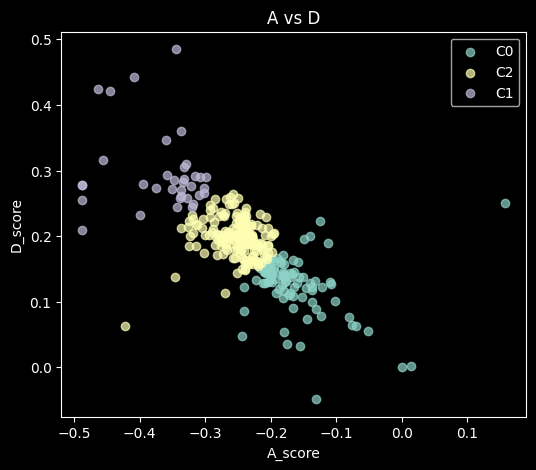

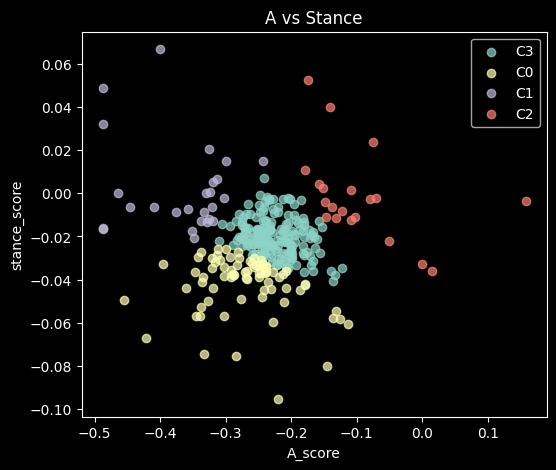

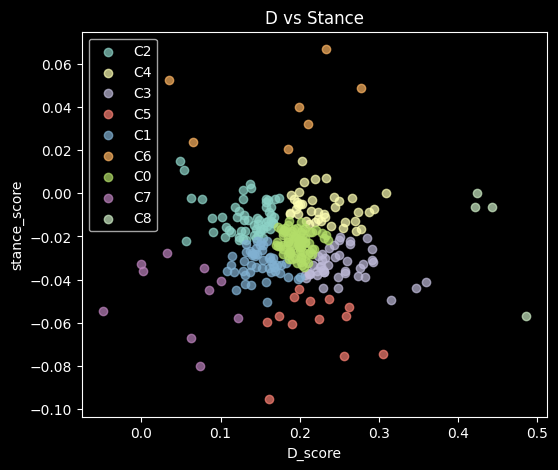

In [12]:
plot_2D(ParlaMint_PS, "A_score", "D_score", "cluster_A_D", "A vs D")
plot_2D(ParlaMint_PS, "A_score", "stance_score", "cluster_A_Stance", "A vs Stance")
plot_2D(ParlaMint_PS, "D_score", "stance_score", "cluster_D_Stance", "D vs Stance")

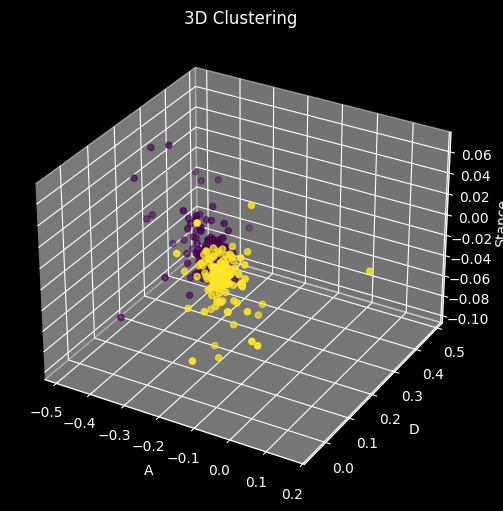

In [13]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    ParlaMint_PS["A_score"],
    ParlaMint_PS["D_score"],
    ParlaMint_PS["stance_score"],
    c=ParlaMint_PS["cluster_3D"]
)

ax.set_xlabel("A")
ax.set_ylabel("D")
ax.set_zlabel("Stance")

plt.title("3D Clustering")
plt.show()

In [14]:
print(results_2D)
print("3D scores:", scores_3D)

{'A_D': {'k': 3, 'scores': [0.4190407418319988, 0.44410358692335805, 0.4018368026079323, 0.38561959509635835, 0.39220248175243144, 0.3507586991555905, 0.3273412258358705, 0.36383167272705663]}, 'A_Stance': {'k': 4, 'scores': [0.3048511961023907, 0.30839757663010614, 0.3462801284616371, 0.3187637983754686, 0.30213016728844316, 0.32408457893067355, 0.3034280080980055, 0.3181231515474415]}, 'D_Stance': {'k': 9, 'scores': [0.28331959588642597, 0.2877165835490645, 0.2915193489966611, 0.3001099580579497, 0.3153241755644183, 0.3171057284484995, 0.32415924622533937, 0.3286072285833223]}}
3D scores: [0.28731642438484317, 0.28674480230562904, 0.27390454335505093, 0.25574952332004863, 0.27188521207231336, 0.258498832268706, 0.2696899155400911, 0.2677573035899363]


In [15]:
pd.crosstab(ParlaMint_PS["cluster_3D"], ParlaMint_PS["party_ref"])

party_ref,TK,party.50PLUS,party.CDA,party.ChristenUnie,party.D66,party.DENK,party.FvD,party.GroenLinks,party.GroepBontes-VanKlaveren,party.Houwers,party.Klein,party.PVV,party.PvdA,party.PvdD,party.SGP,party.SP,party.VOLT,party.VVD,party.VanVliet
cluster_3D,,,,,,,,,,,,,,,,,,,
0,0,0,16,7,20,2,0,12,1,1,0,15,29,4,3,14,1,40,1
1,1,6,12,4,17,2,4,8,1,0,1,12,19,4,1,10,0,33,0


In [16]:
ParlaMint_PS2=ParlaMint_PS.copy()

In [17]:
ParlaMint_PS2.to_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint_PS2.xlsx", index=False)

In [ ]:
ParlaMint_PS2= pd.read_excel(Path("..")/"HCSS_Exam_2026"/"Intermediary_files"/"ParlaMint_PS2.xlsx")

In [ ]:
#IDK why David Prior specifically does not have his data in here, but it's relatively inconsequential.
df3.loc[df3["date"].isna()]